Recommended promoter non-template strand :  TTCTAATACGACTCACTATAGGGAGT
Recommended O1 Output non-template strand:  ACTCCCCTACATCCACATACTAATTAAC
Recommended dART template strand sequence:  GTTAATTAGTATGTGGATGTAGGGGAGTCTCTCGGCGTGGGGTGGTAGGCTGTAAAGGGGGTCACTCCCTATAGTGAGTCGTATTAGAA
RNA Transcript with i/i' domains:  GGGAGUGACCCCCUUUACAGCCUACCACCCCACGCCGAGAGACUCCCCUACAUCCACAUACUAAUUAAC
Dot-Bracket Notation: ((((((......((((.(.((............)).)))))))))))......................
Minimum Free Energy (MFE): -9.100000381469727 kcal/mol

RNA transcript with recommended insulation domains is favorable. All insulation domain basepair probabilities are above the threshold of 0.9
Base pair probabilities between the first 6 bases and bases after 6 + length of aptamer 35:


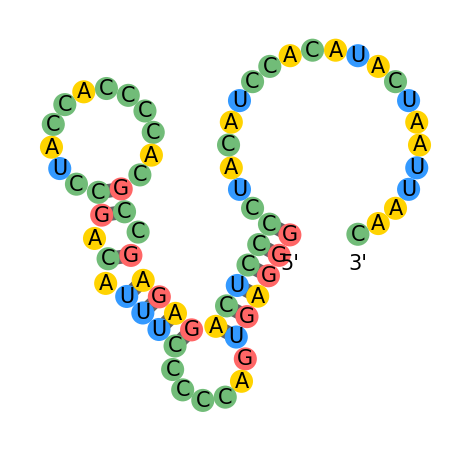

Basepair probability(1,47) = 0.9311
Basepair probability(2,46) = 0.9410
Basepair probability(3,45) = 0.9448
Basepair probability(4,44) = 0.9483
Basepair probability(5,43) = 0.9482
Basepair probability(6,42) = 0.9333


In [2]:
import RNA
import matplotlib.pyplot as plt
from draw_rna.ipynb_draw import draw_struct
import numpy as np

# Define input sequence and complementary sequences
Prom_nt = "TTCTAATACGACTCACTATA"
Prom_t = "TATAGTGAGTCGTATTA GAA"
O1_nt = "CTACATCCACATACTAATTAAC"
O1_t = "GTTAATTAGTATGTGGATGTAG"
i_1 = "GGGATG"
i_1_comp = "CATCCC"
i_2 = "GGGAGT"
i_2_comp = "ACTCCC"
i_3 = "GGGAGA"
i_3_comp = "TCTCCC"
i_4 = "GGGAAA"
i_4_comp = "TTTCCC"


# Define threshold for basepair probability
bp_threshold=0.9

# Function to create the dART template strand
def create_dART_template(aptamer, insulation, insulation_comp):
    encoded_domain = f"{O1_t} {insulation} {aptamer} {insulation_comp}"
    dART_template = f"{encoded_domain} {Prom_t}"
    
    return dART_template.replace(" ", ""), encoded_domain.replace(" ", "")
    
# Function to create encoded RNA transcript
def get_rna_transcript(encoded_sequence): 
    complement = {'A': 'U', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement[base] for base in reversed(encoded_sequence))

# @ Geoff the AI needs to provide aptamers sequences, which is pretty much fed to the following code:
aptamer = "CTCTCGGCGTGGGGTGGTAGGCTGTAAAGGGGGTC" # Insert aptamer sequence here.
aptamer_length = len(aptamer) # Check length of aptamer to ensure position of insulation domains and very the insulation domains are bound


def calculate_insulation_bpp(aptamer, insulation, insulation_comp):
    dART_template = create_dART_template(aptamer, insulation, insulation_comp)[0]
    encoded_RNA = create_dART_template(aptamer, insulation, insulation_comp)[1] 
    # Generate the complementary RNA sequence
    rna_transcript = get_rna_transcript(encoded_RNA)
    # fold RNA transcript at 37
    RNA.cvar.temperature = 37
    (structure, mfe) = RNA.fold(rna_transcript)
    fc = RNA.fold_compound(rna_transcript)
    fc.pf()
    basepair_probs = fc.bpp()
    start_region = range(7)
    target_region = range(6 + aptamer_length, 6 + aptamer_length + 8)
    binding_count = 0
    
    # Check if the binding count condition is met
    for i in start_region:
        for j in target_region:
            prob = basepair_probs[i][j]
            if prob > bp_threshold:
                binding_count += 1
    
    # Only print probabilities if the condition is met
    if binding_count == 6:
        print("Recommended promoter non-template strand : ", Prom_nt + insulation)
        print("Recommended O1 Output non-template strand: ", insulation_comp+O1_nt)
        print("Recommended dART template strand sequence: ", create_dART_template(aptamer, insulation, insulation_comp)[0])
        # Fold RNA transcript at 37C
        print("RNA Transcript with i/i' domains: ", rna_transcript)
        print("Dot-Bracket Notation:", structure)
        print("Minimum Free Energy (MFE):", mfe, "kcal/mol")
        print(f"\nRNA transcript with recommended insulation domains is favorable. All insulation domain basepair probabilities are above the threshold of {bp_threshold}")
        print(f"Base pair probabilities between the first 6 bases and bases after 6 + length of aptamer {aptamer_length}:")
        draw_struct(rna_transcript, structure) # OPTIONAL FEATURE - Draws secondary structure of RNA
        for i in start_region:
            for j in target_region:
                prob = basepair_probs[i][j]
                if prob > bp_threshold:
                    print(f"Basepair probability({i},{j}) = {prob:.4f}")

    else:
        None

calculate_insulation_bpp(aptamer, i_1, i_1_comp)
calculate_insulation_bpp(aptamer, i_2, i_2_comp)
calculate_insulation_bpp(aptamer, i_3, i_3_comp)
calculate_insulation_bpp(aptamer, i_4, i_4_comp)